Viewing the results generated from [CT_dataset_pipeline.py](../CT_dataset_pipeline.py)

In [6]:
from pathlib import Path

import pandas as pd
import numpy as np

base_dir = Path('/gpfs_projects/brandon.nelson/pedsilicoICH/MIDA_analytical_sphere_ICH')
metadata = pd.read_csv(base_dir / 'metadata.csv')
metadata

,name,contrast,radius,center x,center y,center z,image file,mask file
0,case_000,118,16,329,178,232,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...
1,case_000,118,16,329,178,232,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...
2,case_000,118,16,329,178,232,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...
3,case_000,118,16,329,178,232,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...
4,case_000,118,16,329,178,232,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...
...,...,...,...,...,...,...,...,...
835,case_004,178,16,338,317,214,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...
836,case_004,178,16,338,317,214,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...
837,case_004,178,16,338,317,214,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...
838,case_004,178,16,338,317,214,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...,/gpfs_projects/brandon.nelson/pedsilicoICH/MID...


In [26]:
from pedsilicoICH.image_acquisition import read_dicom
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

from utils import display_settings

def browse_studies(metadata, name='case_000', display='soft tissues', slice_idx=0, f=None, ax=None):
    patient = metadata[(metadata['name']==name)].iloc[slice_idx]
    dcm_file = patient['image file']
    img = read_dicom(dcm_file)
        
    ww, wl = display_settings[display]
    minn = wl - ww/2
    maxx = wl + ww/2
    if (f is None) or (ax is None):
        f, ax = plt.subplots()
    im = ax.imshow(img, cmap='gray', vmin=minn, vmax=maxx)
    plt.colorbar(im, ax=ax, label=f'HU | {display} [ww: {ww}, wl: {wl}]')
    ax.set_title(patient['name'])

def study_viewer(metadata): 
    viewer = lambda **kwargs: browse_studies(metadata, **kwargs)
    slices = list(range(168)) # fix later to be dynamic
    interact(viewer,
             name=metadata.name.unique(),
             display=display_settings.keys(),
             slice_idx=IntSlider(value=slices[len(slices)//2], min=min(slices), max=max(slices)))

In [27]:
study_viewer(metadata)

interactive(children=(Dropdown(description='name', options=('case_000', 'case_001', 'case_002', 'case_003', 'c…

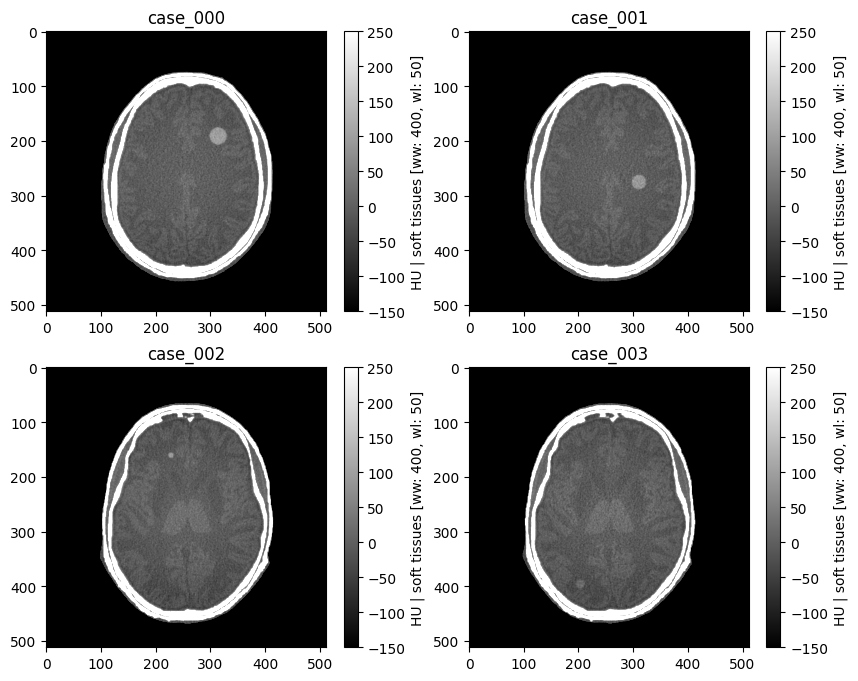

In [37]:
f, axs = plt.subplots(2,2, figsize=(10,8))
browse_studies(metadata, 'case_000', slice_idx=47, f=f, ax=axs[0,0])
browse_studies(metadata, 'case_001', slice_idx=47, f=f, ax=axs[0,1])
browse_studies(metadata, 'case_002', slice_idx=65, f=f, ax=axs[1,0])
browse_studies(metadata, 'case_003', slice_idx=64, f=f, ax=axs[1,1])

In [33]:
metadata.radius.unique()

array([16, 13,  5,  8])

In [34]:
metadata.contrast.unique()

array([118, 100, 121,  53, 178])

In [32]:
metadata['image file'][0], read_dicom(metadata['image file'][0]).shape

('/gpfs_projects/brandon.nelson/pedsilicoICH/MIDA_analytical_sphere_ICH/case_000/dicoms/case_000_000.dcm',
 (512, 512))

In [18]:
from utils import scrollview
vol = np.stack([read_dicom(o) for o in metadata[metadata['name']=='case_001']['image file']])
mask = np.stack([read_dicom(o) for o in metadata[metadata['name']=='case_001']['mask file']])

vol.shape, mask.shape

((168, 512, 512), (168, 512, 512))

In [19]:
scrollview(vol)

interactive(children=(IntSlider(value=84, description='idx', max=167), Output()), _dom_classes=('widget-intera…

In [37]:
scrollview(vol.transpose(1,0,2))

interactive(children=(IntSlider(value=256, description='idx', max=511), Output()), _dom_classes=('widget-inter…

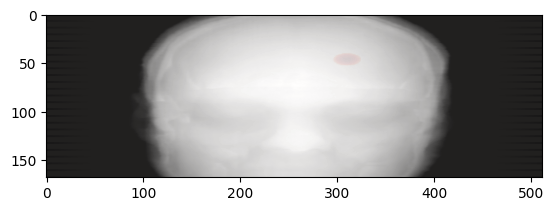

In [22]:
plt.imshow(vol.sum(axis=1), cmap='gray')
plt.imshow(mask.sum(axis=1), cmap='Reds', alpha=0.1)

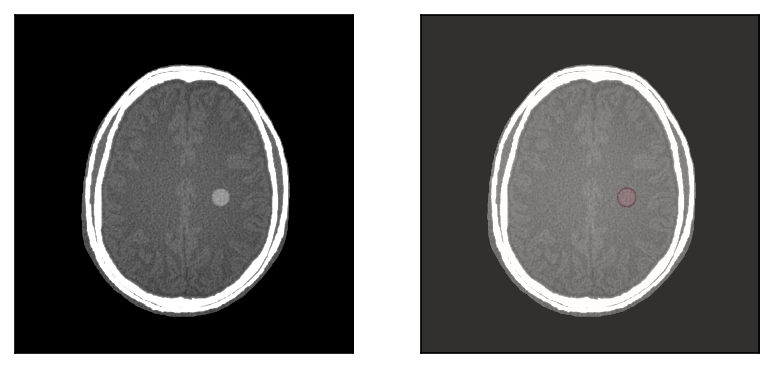

In [30]:
import matplotlib.pyplot as plt
from utils import ctshow

z_idx = np.argmax(mask.sum(axis=1).sum(axis=1))

f, axs = plt.subplots(1,2, dpi=150)
ctshow(vol[z_idx], fig=f, ax=axs[0])
ctshow(vol[z_idx], fig=f, ax=axs[1])
axs[1].imshow(mask[z_idx], cmap='Reds', alpha=0.2)